In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from utils_lstm import LSTMAttentionModel, train_model, evaluate_model, plot_importance, sliding_window_importance
from sklearn.preprocessing import MinMaxScaler

In [5]:
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])

import numpy as np

# Keep features with variance above a threshold
variance_threshold = 0.09
dfs = dfs.loc[:, dfs.var() > variance_threshold]
targets

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022017,0.319825,0.363018,0.600159,0.372211
2,2,0.044033,0.319035,0.401244,0.560835,0.412939
3,2,0.066050,0.317768,0.438220,0.522651,0.452336
4,2,0.088067,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,0.902686,0.641596,0.373375,0.680266,0.314326
14559,318,0.924703,0.640550,0.372634,0.680719,0.313536
14560,318,0.946720,0.640334,0.374073,0.679194,0.315070
14561,318,0.968736,0.641037,0.377992,0.675413,0.319245


In [18]:
angle = 45
# Collect the 6th row's Main-axis value per experiment
selected = []
for exp_id, group in targets.groupby("Experiment_ID"):
    if len(group) > 6:  
        value = group.iloc[angle] # 6th row by position
    else:
        value = np.nan  # if experiment shorter than 7 rows
    selected.append([value])  # wrap in list → keeps (num_experiments, 1)

y = np.array(selected, dtype=float)[:,0,1:]
y = np.array(y)
groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)

X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)
y = np.nan_to_num(y, nan=0.0)[:,2:]
print("Shape:", X.shape, y.shape)  
# Convert to tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y)

Shape: (315, 1743, 6) (315, 3)


In [19]:
model = LSTMAttentionModel(input_size=6, hidden_size=32, output_size=3, dropout=0.3)
model = train_model(model, X_tensor, y_tensor, epochs=5, lr=0.001, batch_size=32, print_every=1)

Training: 100%|██████████| 5/5 [00:09<00:00,  1.88s/epoch, avg_loss=0.00540418]


In [20]:
# Evaluate
output, attn_weights, loss_val = evaluate_model(model, X_tensor, y_tensor)

# Sliding window importance (optional)
importance_scores = sliding_window_importance(model, X_tensor[0], y_tensor[0], window_size=10, stride=5)


Final Loss: 0.00570166
Predicted: [[0.23629667 0.41871992 0.18249619]
 [0.23631522 0.4187456  0.18254584]
 [0.23632382 0.4185932  0.18235242]
 [0.23634253 0.41861907 0.18240222]
 [0.23635978 0.4184738  0.18225123]
 [0.23635046 0.4184609  0.18222636]
 [0.23637772 0.41833374 0.18208274]
 [0.23636833 0.41832078 0.18205786]
 [0.23640434 0.41820094 0.18195683]
 [0.23641342 0.41821346 0.18198144]
 [0.23643166 0.41807327 0.18181325]
 [0.23644088 0.41808602 0.18183798]
 [0.23644903 0.41792727 0.18166259]
 [0.23643042 0.4179015  0.181613  ]
 [0.2364671  0.41778606 0.18149412]
 [0.23648572 0.41781172 0.18154365]
 [0.23646602 0.417614   0.18129417]
 [0.2364753  0.41762677 0.18131886]
 [0.23652135 0.4175237  0.18122491]
 [0.23653062 0.41753647 0.18124966]
 [0.23652965 0.41736397 0.18104981]
 [0.23651096 0.41733825 0.18100028]
 [0.23654786 0.41722208 0.18088172]
 [0.23656644 0.4172476  0.18093109]
 [0.23655607 0.4170616  0.18070655]
 [0.23657468 0.41708705 0.18075587]
 [0.23660237 0.4169577  0.1806

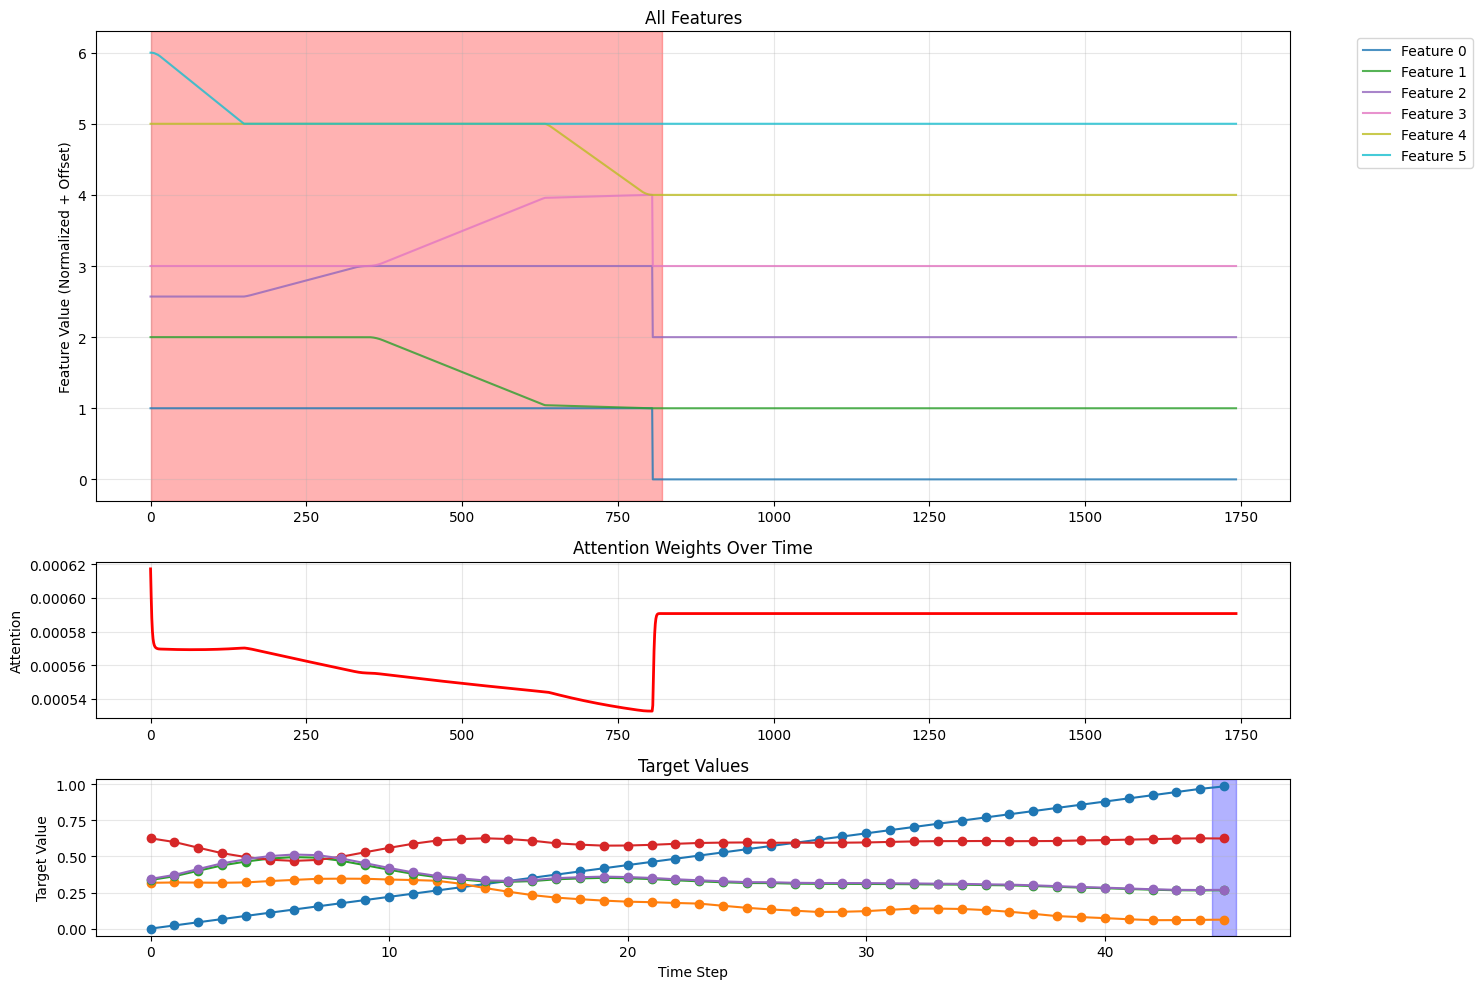

In [21]:
experiment_id = 2
target = targets[targets["Experiment_ID"]==experiment_id].iloc[:, 1:]
# Plot results with highest-attended area highlighted
plot_importance(X[experiment_id-2], scores=importance_scores, target=target, attn_weights=attn_weights[experiment_id-2],top_n=10, target_angle=angle)